In [ ]:
import os
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from utils import *

with open(obs_labels_path, "rb") as f:
    obs_data_dict = pickle.load(f)

with open(attack_labels_path, "rb") as f:
    beh_data_dict = pickle.load(f)

setup_plot_style()

In [2]:
mouse_id_list = list(obs_data_dict.keys())[: -1] # get rid of the familiar vs novel first

mouse_pred_dict_full = {}
for idx, mouse_id in enumerate(mouse_id_list):
    pred_d_s_pd = obs_data_dict[mouse_id]
    mouse_pred_dict = {}
    for day_idx in np.arange(1, 9):
        for session_idx in np.arange(1, 4):
            pred_d_s = pred_d_s_pd[(pred_d_s_pd["day_id"] == day_idx) & (pred_d_s_pd["session_id"] == session_idx)]
            if len(pred_d_s) == 0:
                print(f"No data for {mouse_id} day {day_idx} session {session_idx}")
                continue
            pred_smpl = label_to_categories(pred_d_s["prediction"].values)
            smoothed_pred_d_s_categories = rolling_mode_fast(pred_smpl)
            concat_pred = np.stack([pred_d_s["prediction"].values, pred_smpl, smoothed_pred_d_s_categories])
            mouse_pred_dict[f"d{day_idx}_s{session_idx}"] = concat_pred
    mouse_pred_dict_full[mouse_id] = mouse_pred_dict

In [3]:
def simulate_start_end_indices(durations, session_length, occupied = None):
    """
    Generate non-overlapping start and end indices for segments with given durations.
    Uses random placement to avoid overlaps.
    
    Parameters:
    -----------
    durations : list or array-like
        List of segment durations (in frames)
    session_length : int
        Total length of the session (in frames)
    occupied : array-like, optional
        Array of occupied frames (in frames)
    
    Returns:
    --------
    list of tuples
        List of (start_idx, end_idx) tuples for non-overlapping segments
    """
    # Binary array to track occupied frames
    if occupied is None:
        occupied = np.zeros(session_length, dtype=bool)
    start_end_indices = []
    
    for duration in durations:
        # Try to find a random valid start position
        max_attempts = 1000  # Prevent infinite loops
        attempts = 0
        
        while attempts < max_attempts:
            # Random start index that allows the full duration to fit
            max_start = session_length - duration
            if max_start < 0:
                # Duration is longer than session, skip this segment
                break
                
            start_idx = np.random.randint(0, max_start + 1)
            end_idx = start_idx + duration
            
            # Check if this segment overlaps with any occupied frames
            if not np.any(occupied[start_idx:end_idx]):
                # Mark these frames as occupied
                occupied[start_idx:end_idx] = True
                start_end_indices.append((start_idx, int(end_idx)))
                break
            
            attempts += 1
        
        # If we couldn't place this segment after max_attempts, skip it
        if attempts >= max_attempts:
            break
    
    return start_end_indices

In [4]:
obs_mouse_id_list = [k for k, v in label_to_cond_dict.items() if v == "obs"]

mtx_len_dict = {}
day_sesh_labels = []
day_sesh_labels_other = []

for idx, mouse_id in enumerate(obs_mouse_id_list):
    pred_full = obs_data_dict[mouse_id]
    pred_full['attack_labels'] = 0
    
    # Calculate matrix length for this mouse and build day_sesh_labels once
    pred_d_s_list = []
    for d_idx in np.arange(1, 9):
        for s_idx in np.arange(1, 4):
            pred_d_s = pred_full[(pred_full["day_id"] == d_idx) & (pred_full["session_id"] == s_idx)]
            pred_d_s_list.append(pred_d_s)
            if idx == 0:  # Only add labels once for the first mouse
                day_sesh_labels.append(f"D{d_idx}, S{s_idx}")
                day_sesh_labels_other.append(f"d{d_idx}_s{s_idx}")
                
    sesh_lengths = [len(pred) for pred in pred_d_s_list if len(pred) > 15000]
    if sesh_lengths:
        min_len = np.min(sesh_lengths)  
        mean_len = np.mean(sesh_lengths).astype(int)
        max_len = np.max(sesh_lengths)
        mtx_len_dict[mouse_id] = max_len
        print(mouse_id, min_len, mean_len, max_len, len(sesh_lengths) / 24)
    
    # Add attack labels to predictions
    for d_idx in np.arange(1, 9):
        for s_idx in np.arange(1, 4):
            pred_d_s_arr = mouse_pred_dict_full[mouse_id][f"d{d_idx}_s{s_idx}"]
            attack_labels_d_s = beh_data_dict[f'{mouse_id}_d{d_idx}_obs_t{s_idx}']['attack labels']
            diff = pred_d_s_arr.shape[1] - attack_labels_d_s.shape[0]
            if diff < 0:
                print(f"{mouse_id}, Day {d_idx}, Session {s_idx}, skipped due to missing predictions")
            else:
                attack_labels_d_s_padded = np.concatenate([np.zeros(diff, dtype=attack_labels_d_s.dtype), attack_labels_d_s])
                mouse_pred_dict_full[mouse_id][f"d{d_idx}_s{s_idx}"] = np.concatenate([pred_d_s_arr, attack_labels_d_s_padded.reshape(1, -1)], axis = 0).astype(int)

1185 18928 22377 25023 1.0
30R2 18981 23252 28100 0.9166666666666666
30R2, Day 2, Session 1, skipped due to missing predictions
30R2, Day 4, Session 1, skipped due to missing predictions
30R2, Day 8, Session 1, skipped due to missing predictions
29L 22140 22851 24320 1.0
1162B 21371 23458 31889 1.0
87L2 19580 22896 24763 0.9583333333333334
87L2, Day 8, Session 1, skipped due to missing predictions
933R 17981 23336 25979 1.0
933R, Day 4, Session 2, skipped due to missing predictions
933R, Day 5, Session 2, skipped due to missing predictions
86L 21501 22929 27461 1.0
86L, Day 3, Session 1, skipped due to missing predictions
927R 21382 23857 27326 1.0
927L 22124 23492 25463 1.0


In [5]:
fps = 40
sesh_start_idx = fps * 60 ## trim the first 1 min

attack_onset_frames_states = {}
control_onset_frames_states = {}

for i in categories_label_dict.keys():
    attack_onset_frames_states[i] = []
    control_onset_frames_states[i] = []

for mice_id in obs_mouse_id_list:
    print(f"Processing {mice_id}...")
    mtx_len = mtx_len_dict[mice_id]
    pred_d_s_dict = mouse_pred_dict_full[mice_id]
    pred_d_s_mtx_smpl = np.zeros((24, mtx_len - sesh_start_idx))
    attack_labels_mtx = np.zeros((24, mtx_len - sesh_start_idx))
    
    attack_segment_len = 0
    for idx, pred_d_s in enumerate(pred_d_s_dict.values()):
        attack_labels = pred_d_s[-1, sesh_start_idx: ]
        pred_smpl_smooth = pred_d_s[2, sesh_start_idx: ]
        
        attack_start_stop_indices = find_continuous_ones(attack_labels)
        attack_lengths = [stop_idx - start_idx for start_idx, stop_idx in attack_start_stop_indices]
        
        for start_idx, stop_idx in attack_start_stop_indices:
            attack_segment = pred_smpl_smooth[start_idx: stop_idx]
            for label in categories_label_dict.keys():
                attn_onset = np.where(attack_segment == label)[0]
                if len(attn_onset) > 0:
                    attack_onset_frames_states[label].append(attn_onset[0])
                else:
                    attack_onset_frames_states[label].append(np.inf)
                    
        for _ in range(50):
            control_start_end_indices = simulate_start_end_indices(attack_lengths, len(attack_labels), attack_labels.astype(bool))
            for start_idx, stop_idx in control_start_end_indices:
                control_segment = pred_smpl_smooth[start_idx: stop_idx]
                for label in categories_label_dict.keys():
                    attn_onset = np.where(control_segment == label)[0]
                    if len(attn_onset) > 0:
                        control_onset_frames_states[label].append(attn_onset[0])
                    else:
                        control_onset_frames_states[label].append(np.inf)

Processing 1185...


Processing 30R2...
Processing 29L...
Processing 1162B...
Processing 87L2...
Processing 933R...
Processing 86L...
Processing 927R...
Processing 927L...


In [6]:
attack_props_event = []
attack_mean_time = []
attack_sem_time = []

control_props_event = []
control_mean_time = []
control_sem_time = []

for label, onset_frames in attack_onset_frames_states.items():
    appeared = [t for t in onset_frames if t != np.inf]
    props = len(appeared)/len(onset_frames)
    attack_props_event.append(props)
    attack_mean_time.append(np.mean(appeared))
    attack_sem_time.append(np.std(appeared)/np.sqrt(len(appeared)))
    print(f"{label} appeared in {len(appeared)}/{len(onset_frames)} segments ({100*len(appeared)/len(onset_frames):.1f}%)")
    print(f"When it appeared, mean time = {np.mean(appeared):.1f} frames, sem = {np.std(appeared)/np.sqrt(len(appeared)):.1f}")
    
for label, onset_frames in control_onset_frames_states.items():
    appeared = [t for t in onset_frames if t != np.inf]
    props = len(appeared)/len(onset_frames)
    control_props_event.append(props)
    control_mean_time.append(np.mean(appeared))
    control_sem_time.append(np.std(appeared)/np.sqrt(len(appeared)))
    print(f"{label} appeared in {len(appeared)}/{len(onset_frames)} segments ({100*len(appeared)/len(onset_frames):.1f}%)")
    print(f"When it appeared, mean time = {np.mean(appeared):.1f} frames, sem = {np.std(appeared)/np.sqrt(len(appeared)):.1f}")

1 appeared in 2251/2991 segments (75.3%)
When it appeared, mean time = 7.9 frames, sem = 0.7
2 appeared in 553/2991 segments (18.5%)
When it appeared, mean time = 16.9 frames, sem = 1.9
3 appeared in 473/2991 segments (15.8%)
When it appeared, mean time = 31.7 frames, sem = 3.0
4 appeared in 639/2991 segments (21.4%)
When it appeared, mean time = 36.4 frames, sem = 2.7
1 appeared in 94085/141500 segments (66.5%)
When it appeared, mean time = 10.1 frames, sem = 0.1
2 appeared in 34748/141500 segments (24.6%)
When it appeared, mean time = 20.1 frames, sem = 0.3
3 appeared in 25458/141500 segments (18.0%)
When it appeared, mean time = 30.2 frames, sem = 0.4
4 appeared in 36717/141500 segments (25.9%)
When it appeared, mean time = 34.9 frames, sem = 0.4


In [7]:
# Statistical testing with FDR correction for attack vs control onset times
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Perform t-tests for each behavior
p_values = []
for label in attack_onset_frames_states.keys():
    attack_times = [t for t in attack_onset_frames_states[label] if t != np.inf]
    control_times = [t for t in control_onset_frames_states[label] if t != np.inf]
    
    # Perform two-sample t-test
    t_stat, p_val = stats.ttest_ind(attack_times, control_times)
    p_values.append(p_val)
    print(f"Behavior {label}: t={t_stat:.3f}, p={p_val:.4f}")

# Apply FDR correction
rejected, p_values_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Print corrected p-values
print("\nFDR-corrected p-values:")
for i, (label, p_corr, is_sig) in enumerate(zip(attack_onset_frames_states.keys(), p_values_corrected, rejected)):
    sig_str = "***" if p_corr < 0.001 else ("**" if p_corr < 0.01 else ("*" if p_corr < 0.05 else "ns"))
    print(f"Behavior {label}: p_corrected={p_corr:.4f}, significant={is_sig}, {sig_str}")

Behavior 1: t=-2.757, p=0.0058
Behavior 2: t=-1.299, p=0.1938
Behavior 3: t=0.479, p=0.6317
Behavior 4: t=0.540, p=0.5895

FDR-corrected p-values:
Behavior 1: p_corrected=0.0233, significant=True, *
Behavior 2: p_corrected=0.3876, significant=False, ns
Behavior 3: p_corrected=0.6317, significant=False, ns
Behavior 4: p_corrected=0.6317, significant=False, ns


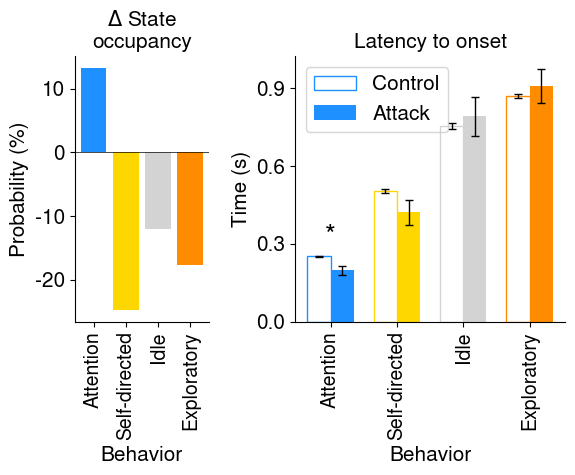

In [8]:
# Add significance stars to the existing figure
fig, axs = plt.subplots(1, 2, figsize=(6, 5), gridspec_kw={'width_ratios': [1, 2]})

fontsize = 15
cat_values = [categories_label_dict[i] for i in range(1, 5)]
diff = (np.array(attack_props_event) - np.array(control_props_event)) / np.array(control_props_event)

axs[0].bar(cat_values, diff * 100, color=categories_cmap)
axs[0].axhline(0, color='black', linewidth=0.5)
axs[0].set_xticks(cat_values, cat_values, fontsize = fontsize - 1, rotation = 90)
axs[0].set_yticks([-20, -10, 0, 10], [-20, -10, 0, 10], fontsize = fontsize)
axs[0].set_ylabel("Probability (%)", fontsize = fontsize)
axs[0].set_xlabel("Behavior", fontsize = fontsize)
axs[0].set_title(r"$\Delta$ State" + "\n" + "occupancy", fontsize = fontsize)

# Create side-by-side bars for attack and control with error bars
x = np.arange(len(cat_values))
width = 0.35

axs[1].bar(x - width/2, np.array(control_mean_time) / fps, width, yerr=np.array(control_sem_time) / fps, 
           color="white", alpha=1.0, label='Control', capsize=3, linewidth=1, edgecolor=categories_cmap, 
           error_kw={'linewidth': 1, 'capthick': 1, "elinewidth": 1})

axs[1].bar(x + width/2, np.array(attack_mean_time) / fps, width, yerr=np.array(attack_sem_time) / fps, 
           color=categories_cmap, alpha=1.0, label='Attack', capsize=3, linewidth=1, 
           error_kw={'linewidth': 1, 'capthick': 1, "elinewidth": 1})


# Add significance stars
for i, (p_corr, is_sig) in enumerate(zip(p_values_corrected, rejected)):
    if is_sig:
        # Determine significance level
        if p_corr < 0.001:
            sig_str = "***"
        elif p_corr < 0.01:
            sig_str = "**"
        elif p_corr < 0.05:
            sig_str = "*"
        else:
            sig_str = ""
        
        # Place star above the higher bar
        y_pos = max(attack_mean_time[i] / fps + attack_sem_time[i] / fps,
                   control_mean_time[i] / fps + control_sem_time[i] / fps) + 0.02
        axs[1].text(x[i], y_pos, sig_str, ha='center', va='bottom', fontsize=20)

axs[1].set_xticks(x, cat_values, fontsize = fontsize - 1, rotation = 90)
axs[1].set_yticks(np.arange(0, 1.1, 0.3), np.round(np.arange(0, 1.1, 0.3), 1), fontsize = fontsize)
axs[1].set_ylabel("Time (s)", fontsize = fontsize)
axs[1].set_xlabel("Behavior", fontsize = fontsize)
axs[1].set_title("Latency to onset", fontsize = fontsize)
axs[1].legend(fontsize = fontsize)

plt.tight_layout()
sns.despine()

plt.savefig(os.path.join(fig_pub_path, "behavioral_categories_appearance_rate_onset_latency.svg"), format="svg")